In [1]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 4.057 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [3]:
import pandas as pd
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")
datafile.groupby('group').describe()

A                                                extra        ...  \
      count  mean      std   min    25%   50%    75%   max count  mean  ...   
group                                                                   ...   
1      10.0   5.5  3.02765   1.0   3.25   5.5   7.75  10.0  10.0  0.75  ...   
2      10.0  15.5  3.02765  11.0  13.25  15.5  17.75  20.0  10.0  2.33  ...   

                    ID                                            
        75%  max count mean      std  min   25%  50%   75%   max  
group                                                             
1      1.70  3.7  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  
2      4.15  5.5  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  

[2 rows x 24 columns]

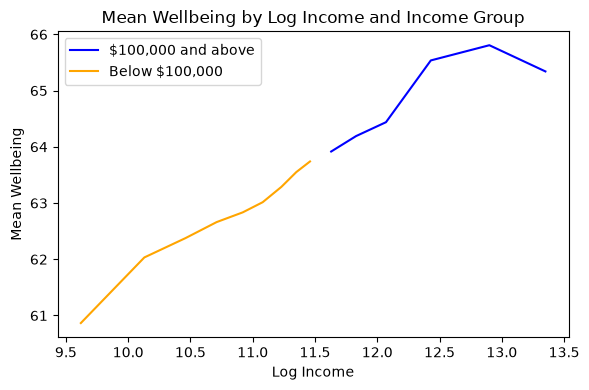

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
source=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/Income2023.csv")
# Aggregate at each observed income value for a readable reproduction of the fitted relationships.
figure_2 = (source.groupby(['income_above_100','income','log_income'], as_index=False)
            .agg(mean_wellbeing=('wellbeing','mean'), n=('wellbeing','size')))
figure_2['income_group'] = np.where(figure_2['income_above_100'].eq(1), '$100,000 and above', 'Below $100,000')
figure_2 = figure_2.sort_values(['income_group','log_income'])
plt.figure(figsize=(6, 4))
plt.plot(figure_2.query("income_group == '$100,000 and above'")['log_income'],
         figure_2.query("income_group == '$100,000 and above'")['mean_wellbeing'], label='$100,000 and above', color='blue')
plt.plot(figure_2.query("income_group == 'Below $100,000'")['log_income'],
         figure_2.query("income_group == 'Below $100,000'")['mean_wellbeing'], label='Below $100,000', color='orange')
plt.xlabel('Log Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Log Income and Income Group')
plt.legend()
plt.tight_layout()
#plt.savefig("C:\\2023_income_wellbeing.png", dpi=300)
plt.show()